# Test 8.2: Lorenz-96 (High-Dimensional Chaos, dim=40)

**Гипотеза:** Свойства V4 (0% dead neurons, стабильная variance) сохраняются на хаотической системе с высокой внутренней размерностью.

**Зачем:**
- Logistic map и Henon — intrinsic dim ~1-2. При K=32 это 32x overcomplete.
- Lorenz-96 с F=8, dim=40 — intrinsic dim ~13-15 (по числу положительных экспонент Ляпунова).
- Если V4 работает на dim=40, значит метод не привязан к тривиальной размерности.

**План:**
- Lorenz-96: dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - x_i + F, i=1..40, F=8
- Генерация 5000 изображений 28x28 из snapshot'ов состояния
- V4 (latent=128, K=32) vs Dense_ReLU_128 vs TopK_ReLU_128 (K=32)
- N=5 прогонов, Welch t-test

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import solve_ivp
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
@tf.function
def chaos_activation(x):
    return tf.sin(8.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def build_ksparse_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_dense_relu_ae(image_size=(28, 28), latent_dim=128):
    h, w = image_size
    input_img = keras.Input(shape=(h, w, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    decoded = layers.Dense(h * w, activation='sigmoid')(x)
    decoded = layers.Reshape((h, w, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return autoencoder, encoder


def build_topk_relu_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    """TopK + ReLU baseline (V3 architecture) for fair sparsity comparison."""
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
    }


print("Core components ready.")

Core components ready.


In [ ]:
def lorenz96_rk4_step(x, F, dt):
    """One RK4 step for Lorenz-96."""
    N = len(x)
    def deriv(state):
        d = np.empty(N)
        for i in range(N):
            d[i] = (state[(i+1) % N] - state[(i-2) % N]) * state[(i-1) % N] - state[i] + F
        return d
    k1 = deriv(x)
    k2 = deriv(x + 0.5*dt*k1)
    k3 = deriv(x + 0.5*dt*k2)
    k4 = deriv(x + dt*k3)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def generate_lorenz96_dataset(num_images, state_dim=40, image_size=28,
                               F=8.0, dt=0.05, spinup_steps=200):
    """
    Generate images from Lorenz-96 system.
    
    Strategy: many independent short trajectories (like logistic map generator).
    Each image = 784 consecutive x_0(t) values from one trajectory.
    """
    pixels_per_image = image_size * image_size  # 784
    images = []
    
    for img_idx in range(num_images):
        # Random initial condition near the attractor
        x = F * np.ones(state_dim) + np.random.randn(state_dim) * 0.5
        
        # Spinup to reach attractor
        for _ in range(spinup_steps):
            x = lorenz96_rk4_step(x, F, dt)
        
        # Collect trajectory (first variable only)
        signal = np.empty(pixels_per_image)
        for step in range(pixels_per_image):
            x = lorenz96_rk4_step(x, F, dt)
            signal[step] = x[0]
        
        # Normalize to [0, 1]
        sig_min, sig_max = signal.min(), signal.max()
        signal = (signal - sig_min) / (sig_max - sig_min + 1e-8)
        images.append(signal.reshape(image_size, image_size))
        
        if (img_idx + 1) % 1000 == 0:
            print(f"  Generated {img_idx+1}/{num_images} images")
    
    images = np.array(images)[..., np.newaxis].astype('float32')
    print(f"Generated {num_images} Lorenz-96 images {images.shape}, "
          f"pixel range: [{images.min():.3f}, {images.max():.3f}]")
    return images


# Logistic map for comparison
def logistic_map(x, r=3.99):
    return r * x * (1 - x)

def generate_logistic_dataset(num_images, image_size=28, r=3.99):
    dataset = []
    for _ in range(num_images):
        x = np.random.rand()
        seq = []
        for _ in range(image_size * image_size):
            x = logistic_map(x, r)
            seq.append(x)
        dataset.append(np.array(seq).reshape(image_size, image_size))
    return np.array(dataset)[..., np.newaxis].astype('float32')


print("Data generators ready.")

Data generators ready.


  Generated 1000/5500 images
  Generated 2000/5500 images
  Generated 3000/5500 images
  Generated 4000/5500 images
  Generated 5000/5500 images
Generated 5500 Lorenz-96 images (5500, 28, 28, 1), pixel range: [0.000, 1.000]

Lorenz-96 train: (5000, 28, 28, 1), test: (500, 28, 28, 1)
Logistic  train: (5000, 28, 28, 1), test: (500, 28, 28, 1)


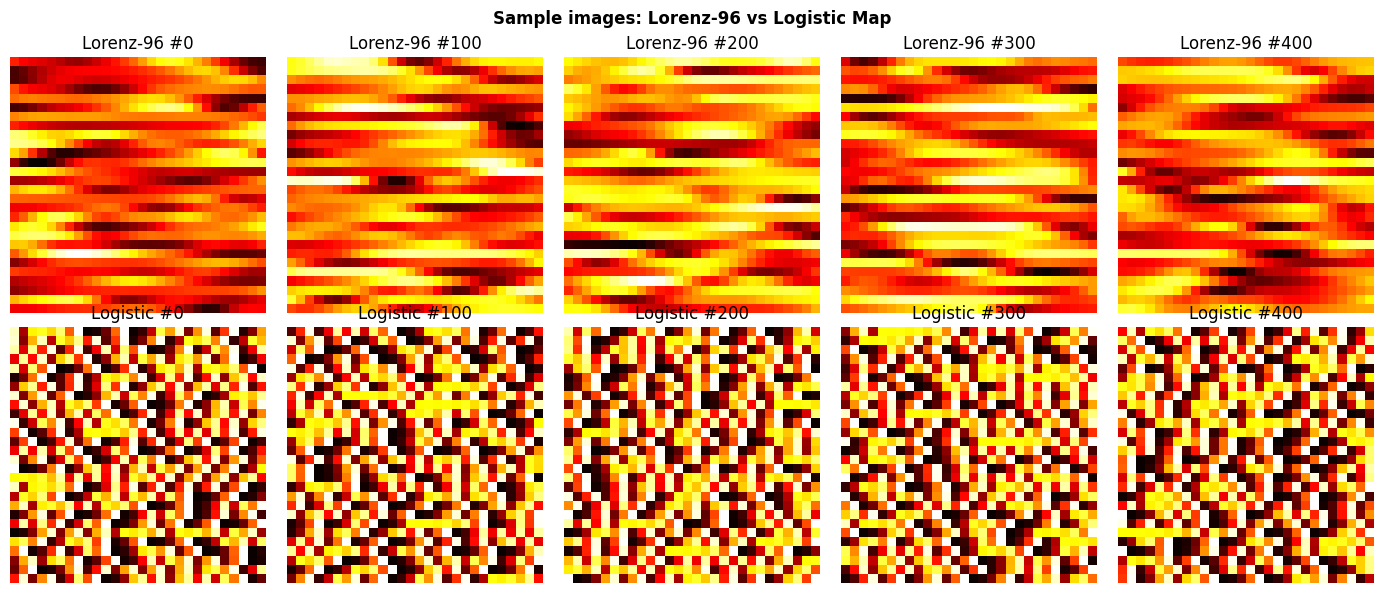

In [ ]:
TRAIN_SIZE = 5000
TEST_SIZE = 500

# Lorenz-96
lorenz_all = generate_lorenz96_dataset(TRAIN_SIZE + TEST_SIZE, state_dim=40, F=8.0)
lorenz_train = lorenz_all[:TRAIN_SIZE]
lorenz_test = lorenz_all[TRAIN_SIZE:]

# Logistic map (for comparison)
np.random.seed(42)
logistic_train = generate_logistic_dataset(TRAIN_SIZE)
logistic_test = generate_logistic_dataset(TEST_SIZE)

print(f"\nLorenz-96 train: {lorenz_train.shape}, test: {lorenz_test.shape}")
print(f"Logistic  train: {logistic_train.shape}, test: {logistic_test.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    axes[0, i].imshow(lorenz_train[i*100, :, :, 0], cmap='hot')
    axes[0, i].set_title(f'Lorenz-96 #{i*100}')
    axes[0, i].axis('off')
    axes[1, i].imshow(logistic_train[i*100, :, :, 0], cmap='hot')
    axes[1, i].set_title(f'Logistic #{i*100}')
    axes[1, i].axis('off')
plt.suptitle('Sample images: Lorenz-96 vs Logistic Map', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 64

architectures = {
    'V4_KSparse_Chaos': lambda: build_ksparse_chaos_ae(latent_dim=128, k_active=32),
    'TopK_ReLU':        lambda: build_topk_relu_ae(latent_dim=128, k_active=32),
    'Dense_ReLU':       lambda: build_dense_relu_ae(latent_dim=128),
}

datasets = {
    'Lorenz96': (lorenz_train, lorenz_test),
    'Logistic': (logistic_train, logistic_test),
}

results = {}

for ds_name, (train_data, test_data) in datasets.items():
    print(f"\n{'='*70}")
    print(f"DATASET: {ds_name}")
    print(f"{'='*70}")
    
    results[ds_name] = {}
    
    for arch_name, builder in architectures.items():
        runs = []
        for run in range(NUM_RUNS):
            np.random.seed(run)
            tf.random.set_seed(run)
            
            ae, enc = builder()
            history = ae.fit(
                train_data, train_data,
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                validation_split=0.1, verbose=0
            )
            s = analyze_latent(enc, test_data)
            s['val_loss'] = history.history['val_loss'][-1]
            runs.append(s)
            print(f"  {arch_name:25s} run {run+1}/{NUM_RUNS}: "
                  f"var={s['mean_variance']:.4f}, "
                  f"dead={s['dead_neurons']:>3d}/128, "
                  f"loss={s['val_loss']:.4f}")
            
            del ae, enc
            keras.backend.clear_session()
        
        results[ds_name][arch_name] = runs

print("\nAll experiments done.")


DATASET: Lorenz96


2026-02-23 22:04:15.133983: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-23 22:04:15.134018: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-23 22:04:15.134025: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-02-23 22:04:15.134055: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 22:04:15.134074: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-23 22:04:15.515934: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  V4_KSparse_Chaos          run 1/5: var=0.4113, dead=  0/128, loss=0.0433
  V4_KSparse_Chaos          run 2/5: var=0.4128, dead=  0/128, loss=0.0433
  V4_KSparse_Chaos          run 3/5: var=0.4131, dead=  0/128, loss=0.0432
  V4_KSparse_Chaos          run 4/5: var=0.4096, dead=  0/128, loss=0.0432
  V4_KSparse_Chaos          run 5/5: var=0.4151, dead=  0/128, loss=0.0432
  TopK_ReLU                 run 1/5: var=1.8399, dead= 12/128, loss=0.0328
  TopK_ReLU                 run 2/5: var=1.6615, dead= 14/128, loss=0.0321
  TopK_ReLU                 run 3/5: var=1.9135, dead= 14/128, loss=0.0321
  TopK_ReLU                 run 4/5: var=1.8849, dead= 11/128, loss=0.0325
  TopK_ReLU                 run 5/5: var=1.7435, dead= 12/128, loss=0.0319
  Dense_ReLU                run 1/5: var=0.5502, dead=  0/128, loss=0.0265
  Dense_ReLU                run 2/5: var=0.6177, dead=  0/128, loss=0.0310
  Dense_ReLU                run 3/5: var=0.5647, dead=  0/128, loss=0.0286
  Dense_ReLU             

In [ ]:
print(f"{'Dataset':<12} {'Architecture':<25} {'Variance':>16} {'Dead':>10} {'Val Loss':>14}")
print('-' * 80)

summary = {}

for ds_name in datasets:
    summary[ds_name] = {}
    for arch_name in architectures:
        runs = results[ds_name][arch_name]
        v = [r['mean_variance'] for r in runs]
        d = [r['dead_neurons'] for r in runs]
        l = [r['val_loss'] for r in runs]
        
        row = {
            'var_mean': np.mean(v), 'var_std': np.std(v),
            'dead_mean': np.mean(d), 'dead_std': np.std(d),
            'loss_mean': np.mean(l), 'loss_std': np.std(l),
            'variances': v, 'deads': d,
        }
        summary[ds_name][arch_name] = row
        
        print(f"{ds_name:<12} {arch_name:<25} "
              f"{row['var_mean']:.4f} +/- {row['var_std']:.4f} "
              f"{row['dead_mean']:>5.1f} +/- {row['dead_std']:.1f} "
              f"{row['loss_mean']:.4f} +/- {row['loss_std']:.4f}")
    print()

Dataset      Architecture                      Variance       Dead       Val Loss
--------------------------------------------------------------------------------
Lorenz96     V4_KSparse_Chaos          0.4124 +/- 0.0018   0.0 +/- 0.0 0.0432 +/- 0.0000
Lorenz96     TopK_ReLU                 1.8087 +/- 0.0935  12.6 +/- 1.2 0.0323 +/- 0.0003
Lorenz96     Dense_ReLU                0.5709 +/- 0.0292   0.0 +/- 0.0 0.0286 +/- 0.0014

Logistic     V4_KSparse_Chaos          0.4133 +/- 0.0031   0.0 +/- 0.0 0.1166 +/- 0.0001
Logistic     TopK_ReLU                 1.1074 +/- 0.0990  13.2 +/- 4.1 0.1126 +/- 0.0003
Logistic     Dense_ReLU                0.3857 +/- 0.0915   0.0 +/- 0.0 0.1198 +/- 0.0017



In [ ]:
print("STATISTICAL COMPARISONS (Welch t-test)")
print('=' * 70)

comparisons = [
    ('V4_KSparse_Chaos', 'TopK_ReLU', 'V4 vs TopK+ReLU (same sparsity)'),
    ('V4_KSparse_Chaos', 'Dense_ReLU', 'V4 vs Dense_ReLU (no sparsity)'),
]

for ds_name in datasets:
    print(f"\n--- {ds_name} ---")
    for arch1, arch2, label in comparisons:
        v1 = summary[ds_name][arch1]['variances']
        v2 = summary[ds_name][arch2]['variances']
        d1 = summary[ds_name][arch1]['dead_mean']
        d2 = summary[ds_name][arch2]['dead_mean']
        
        t_stat, p_val = stats.ttest_ind(v1, v2, equal_var=False)
        ratio = np.mean(v1) / np.mean(v2) if np.mean(v2) > 0 else float('inf')
        
        sig = 'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'
        print(f"  {label}:")
        print(f"    Variance: {np.mean(v1):.4f} vs {np.mean(v2):.4f} (ratio={ratio:.2f}x, p={p_val:.6f}, {sig})")
        print(f"    Dead:     {d1:.1f} vs {d2:.1f}")

STATISTICAL COMPARISONS (Welch t-test)

--- Lorenz96 ---
  V4 vs TopK+ReLU (same sparsity):
    Variance: 0.4124 vs 1.8087 (ratio=0.23x, p=0.000007, SIGNIFICANT)
    Dead:     0.0 vs 12.6
  V4 vs Dense_ReLU (no sparsity):
    Variance: 0.4124 vs 0.5709 (ratio=0.72x, p=0.000396, SIGNIFICANT)
    Dead:     0.0 vs 0.0

--- Logistic ---
  V4 vs TopK+ReLU (same sparsity):
    Variance: 0.4133 vs 1.1074 (ratio=0.37x, p=0.000148, SIGNIFICANT)
    Dead:     0.0 vs 13.2
  V4 vs Dense_ReLU (no sparsity):
    Variance: 0.4133 vs 0.3857 (ratio=1.07x, p=0.579811, NOT significant)
    Dead:     0.0 vs 0.0


In [ ]:
print("CROSS-DATASET GENERALIZATION")
print('=' * 70)

for arch_name in architectures:
    log_var = summary['Logistic'][arch_name]['var_mean']
    lor_var = summary['Lorenz96'][arch_name]['var_mean']
    log_dead = summary['Logistic'][arch_name]['dead_mean']
    lor_dead = summary['Lorenz96'][arch_name]['dead_mean']
    
    ratio = lor_var / log_var if log_var > 0 else float('inf')
    
    print(f"\n{arch_name}:")
    print(f"  Logistic: var={log_var:.4f}, dead={log_dead:.1f}")
    print(f"  Lorenz96: var={lor_var:.4f}, dead={lor_dead:.1f}")
    print(f"  Ratio (Lorenz/Logistic): {ratio:.2f}x")

# Verdict
print('\n' + '='*70)
v4_lor = summary['Lorenz96']['V4_KSparse_Chaos']
topk_lor = summary['Lorenz96']['TopK_ReLU']

v4_zero_dead = v4_lor['dead_mean'] == 0
topk_has_dead = topk_lor['dead_mean'] > 0
v4_high_var = v4_lor['var_mean'] > 0.1

print(f"V4 zero dead on Lorenz-96:          {'YES' if v4_zero_dead else 'NO'}")
print(f"TopK+ReLU has dead on Lorenz-96:    {'YES' if topk_has_dead else 'NO'}")
print(f"V4 variance > 0.1 on Lorenz-96:     {'YES' if v4_high_var else 'NO'}")

if v4_zero_dead and v4_high_var:
    print("\nHYPOTHESIS SUPPORTED: V4 generalizes to high-dimensional chaos.")
else:
    print("\nHYPOTHESIS NOT SUPPORTED. See details above.")

CROSS-DATASET GENERALIZATION

V4_KSparse_Chaos:
  Logistic: var=0.4133, dead=0.0
  Lorenz96: var=0.4124, dead=0.0
  Ratio (Lorenz/Logistic): 1.00x

TopK_ReLU:
  Logistic: var=1.1074, dead=13.2
  Lorenz96: var=1.8087, dead=12.6
  Ratio (Lorenz/Logistic): 1.63x

Dense_ReLU:
  Logistic: var=0.3857, dead=0.0
  Lorenz96: var=0.5709, dead=0.0
  Ratio (Lorenz/Logistic): 1.48x

V4 zero dead on Lorenz-96:          YES
TopK+ReLU has dead on Lorenz-96:    YES
V4 variance > 0.1 on Lorenz-96:     YES

HYPOTHESIS SUPPORTED: V4 generalizes to high-dimensional chaos.


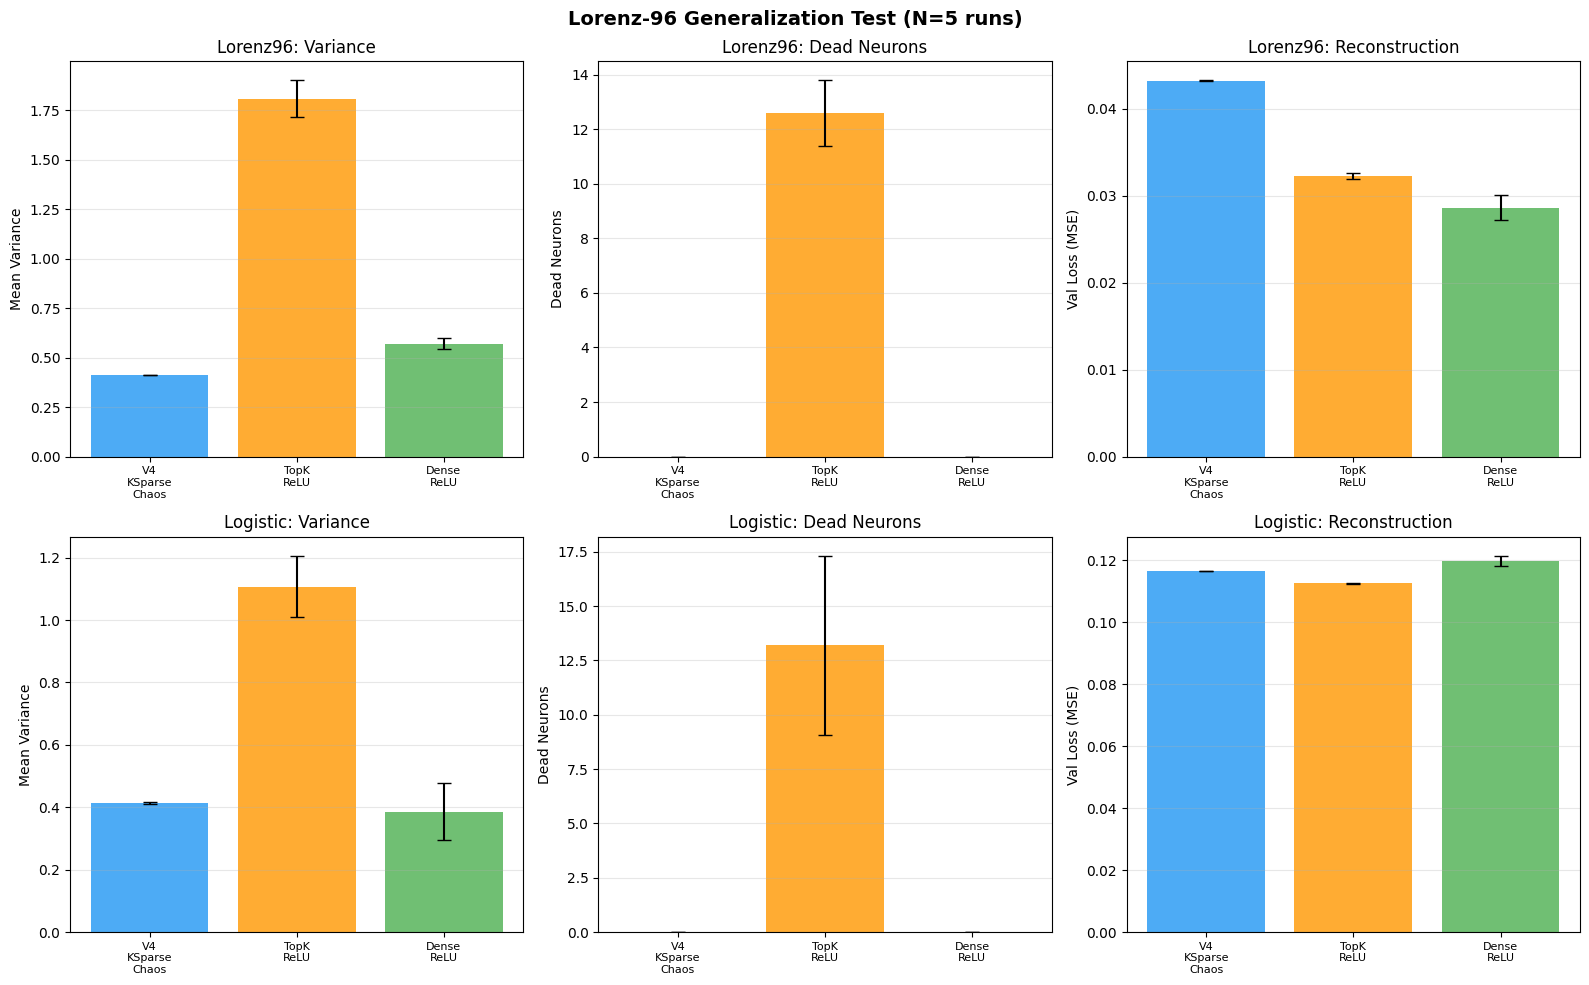

Saved: images/lorenz96_test.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

arch_names = list(architectures.keys())
x_pos = np.arange(len(arch_names))
colors = ['#2196F3', '#FF9800', '#4CAF50']

for row, ds_name in enumerate(datasets):
    # Variance
    means = [summary[ds_name][a]['var_mean'] for a in arch_names]
    stds = [summary[ds_name][a]['var_std'] for a in arch_names]
    axes[row, 0].bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    axes[row, 0].set_xticks(x_pos)
    axes[row, 0].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
    axes[row, 0].set_ylabel('Mean Variance')
    axes[row, 0].set_title(f'{ds_name}: Variance')
    axes[row, 0].grid(True, alpha=0.3, axis='y')

    # Dead neurons
    dead_means = [summary[ds_name][a]['dead_mean'] for a in arch_names]
    dead_stds = [summary[ds_name][a]['dead_std'] for a in arch_names]
    axes[row, 1].bar(x_pos, dead_means, yerr=dead_stds, capsize=5, color=colors, alpha=0.8)
    axes[row, 1].set_xticks(x_pos)
    axes[row, 1].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
    axes[row, 1].set_ylabel('Dead Neurons')
    axes[row, 1].set_title(f'{ds_name}: Dead Neurons')
    axes[row, 1].grid(True, alpha=0.3, axis='y')

    # Val loss
    loss_means = [summary[ds_name][a]['loss_mean'] for a in arch_names]
    loss_stds = [summary[ds_name][a]['loss_std'] for a in arch_names]
    axes[row, 2].bar(x_pos, loss_means, yerr=loss_stds, capsize=5, color=colors, alpha=0.8)
    axes[row, 2].set_xticks(x_pos)
    axes[row, 2].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
    axes[row, 2].set_ylabel('Val Loss (MSE)')
    axes[row, 2].set_title(f'{ds_name}: Reconstruction')
    axes[row, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Lorenz-96 Generalization Test (N={NUM_RUNS} runs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/lorenz96_test.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/lorenz96_test.png")

In [ ]:
save_data = {
    'experiment': 'lorenz96_generalization',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'train_size': TRAIN_SIZE, 'test_size': TEST_SIZE,
        'num_runs': NUM_RUNS, 'epochs': EPOCHS,
        'lorenz96': {'state_dim': 40, 'F': 8.0},
    },
    'summary': {
        ds: {
            arch: {k: v for k, v in vals.items() if k not in ('variances', 'deads')}
            for arch, vals in archs.items()
        }
        for ds, archs in summary.items()
    },
}

json_path = f'../jsons/lorenz96_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/lorenz96_results_20260223_221504.json
